In [3]:
import sys
from pathlib import Path

sys.path.insert(0, '../../')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

ext = 'png'
plot_dir = Path(f'validation_fiber_assignment_thetacut_{ext}')
plot_dir.mkdir(exist_ok=True)

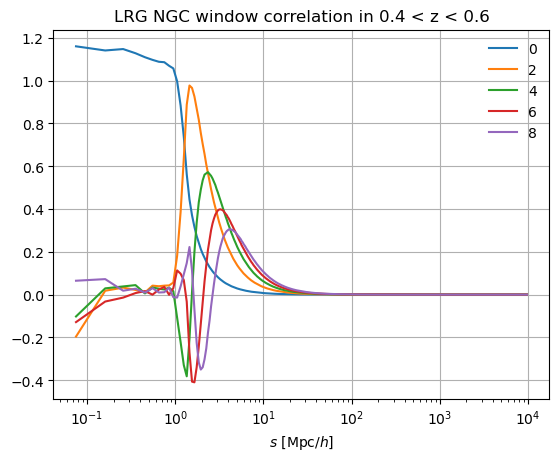

In [2]:
stats_dir = tools.base_stats_dir

for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO'][:1]:
    for zrange in tools.propose_fiducial('zranges', tracer)[:1]:
        for kind in ['mesh2_spectrum']:
            npt = 2 if '2' in kind else 3
            region = 'NGC'
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_smooth_particle{npt:d}_correlation_cut',
                                    version='abacus-hf-dr2-v2-altmtl', tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                                    basis='sugiyama-diagonal', extra='complete', imock=0, battrs={'s': None, 'pole': None})
            window_correlation_particle = types.read(fn)
            
            fig, ax = plt.subplots()
            ax.set_title(f'{tracer} {region} window correlation in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            ells = [label['ells'] for label in window_correlation_particle.labels(level=None)]
            for ill, ell in enumerate(ells):
                color = f'C{ill:d}'
                pole_particle = window_correlation_particle.get(ells=ell)#.select(s=(0.2, 1e3))
                ax.plot(s:=pole_particle.coords('s'), pole_particle.value(), color=color, linestyle='-', label=ell)
            ax.legend(frameon=False)
            ax.set_xscale('log')
            ax.set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
            ax.grid(True)
            plt.show()

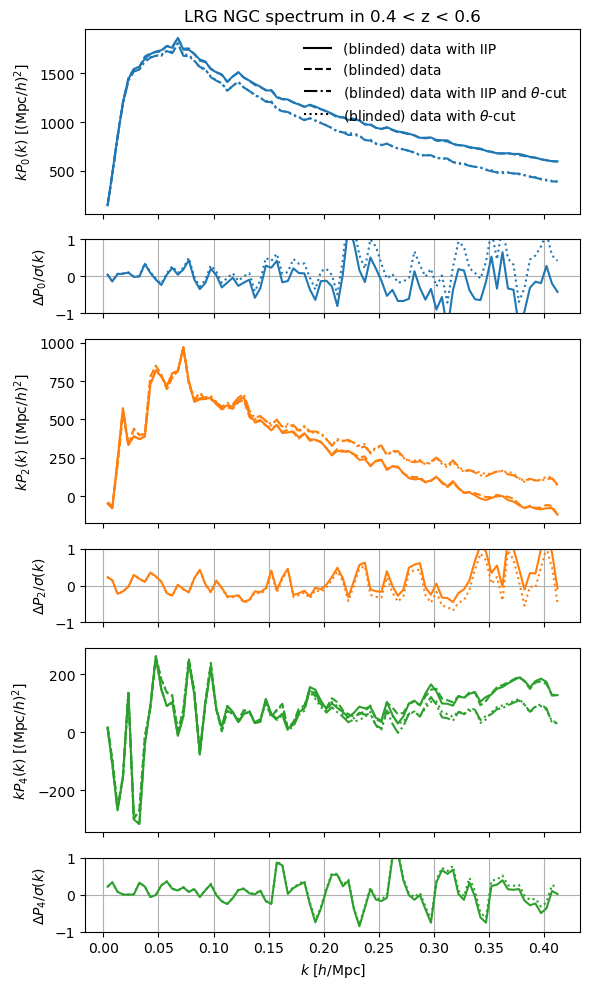

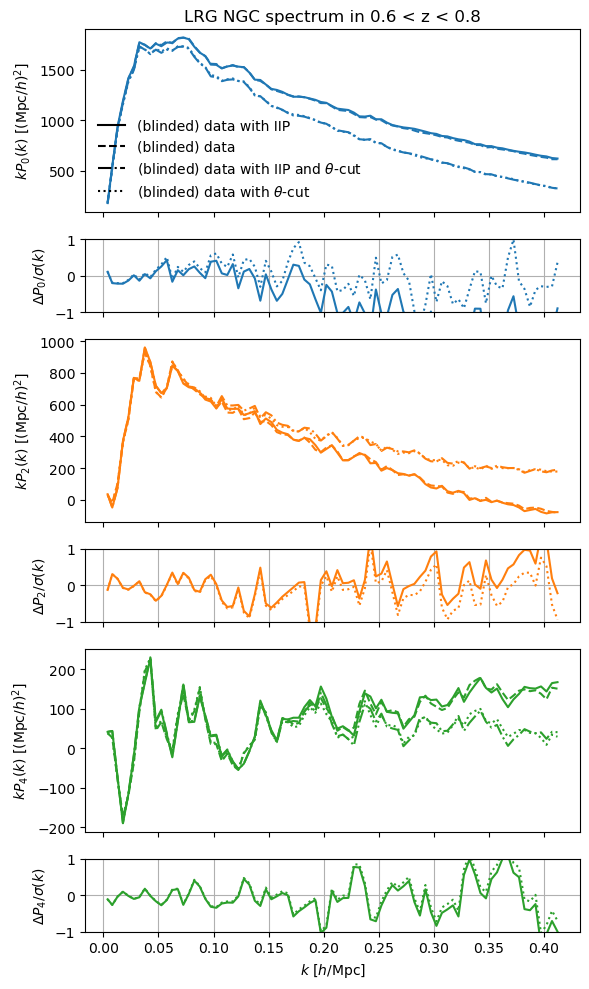

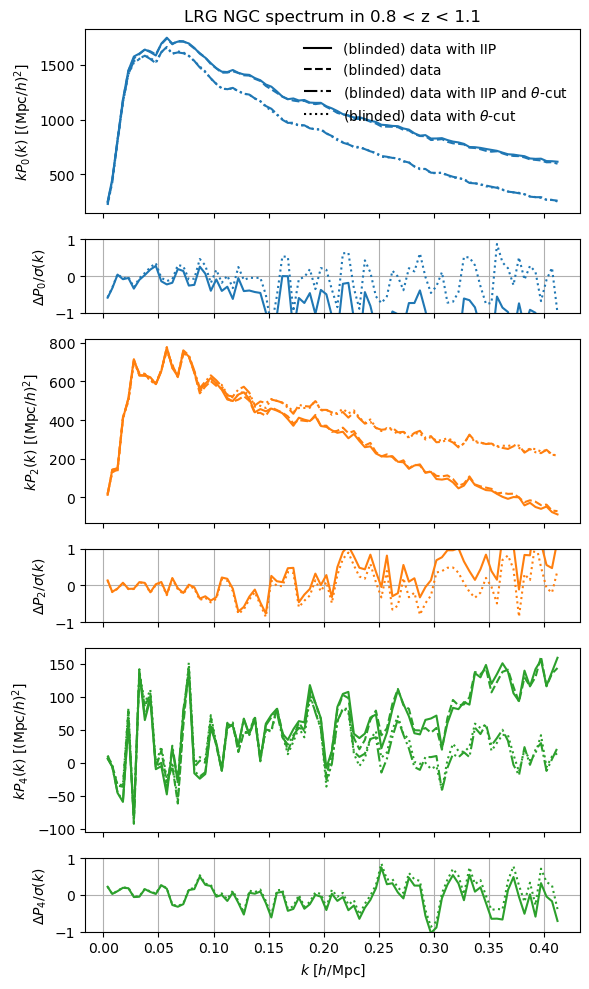

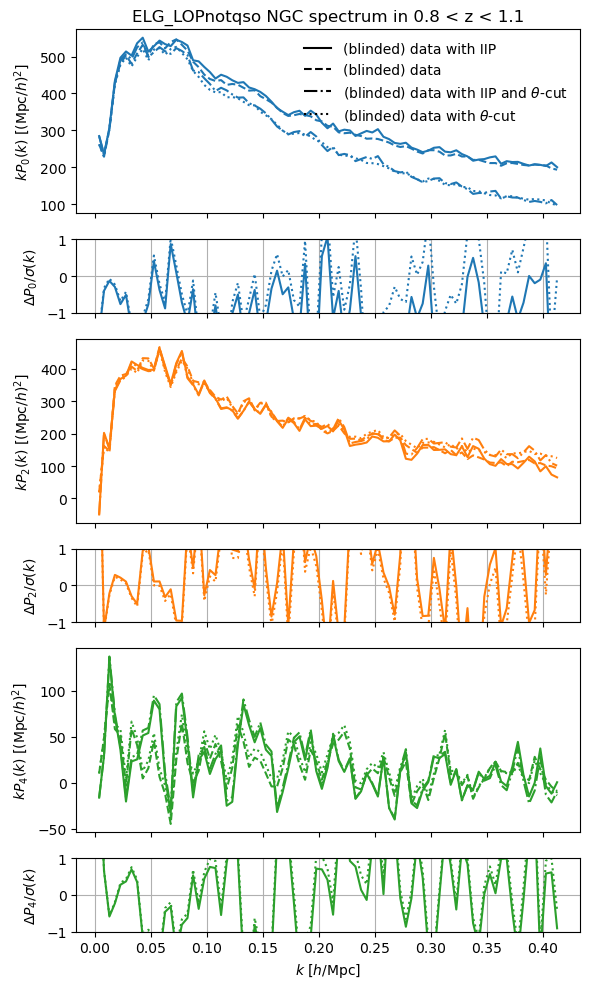

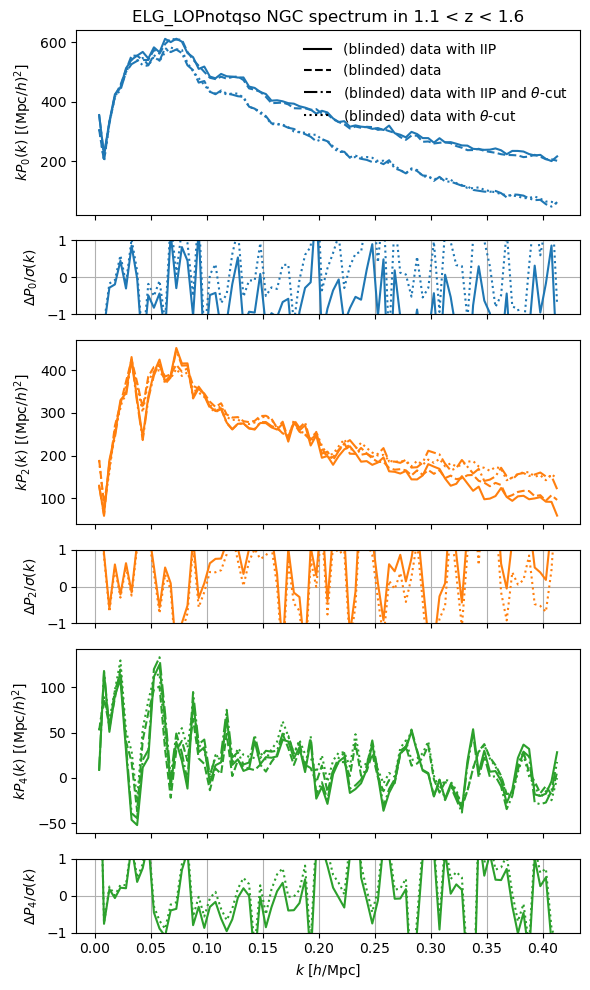

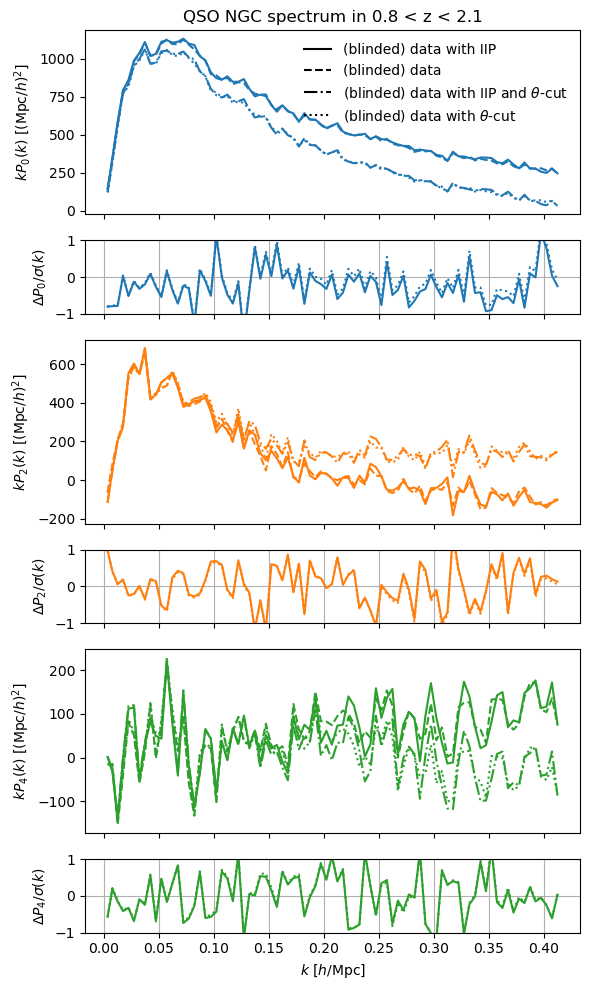

In [4]:
with_thetacut = True

for tracer in ['BGS_BRIGHT-21.35', 'LRG', 'ELG_LOPnotqso', 'QSO'][1:]:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum']:
            stats_dir = tools.base_stats_dir
            project = 'full_shape/fiber_assignment_systematics_tests'
            region = 'NGC'

            version = 'holi-v3-altmtl'
            if 'BGS' in tracer:
                version = 'holi-bgs-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean = cov.observable

            version = 'data-dr2-v2'
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal')

            mocks = types.read(fn)
            mean = mocks.match(mean)

            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP-bitwise-iip', basis='sugiyama-diagonal')
            mocks = types.read(fn)
            mean_complete = mocks.match(mean)

            if with_thetacut:
                fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                          zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', cut=True)
                mocks = types.read(fn)
                mean_thetacut = mocks.match(mean)
                fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                          zrange=zrange, region=region, weight='default-FKP-bitwise-iip', basis='sugiyama-diagonal', cut=True)
                mocks = types.read(fn)
                mean_complete_thetacut = mocks.match(mean)

            if 'mesh2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    if with_thetacut:
                        pole = mean_complete_thetacut.get(ell)
                        ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-.')
                        pole = mean_thetacut.get(ell)
                        ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle='-')
                    if with_thetacut:
                        pole = mean_thetacut.get(ell)
                        pole_complete = mean_complete_thetacut.get(ell)
                        ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='(blinded) data with IIP')
                ax.plot([], [], color='k', linestyle='--', label='(blinded) data')
                if with_thetacut:
                    ax.plot([], [], color='k', linestyle='-.', label=r'(blinded) data with IIP and $\theta$-cut')
                    ax.plot([], [], color='k', linestyle=':', label=r'(blinded) data with $\theta$-cut')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_data_thetacut_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()

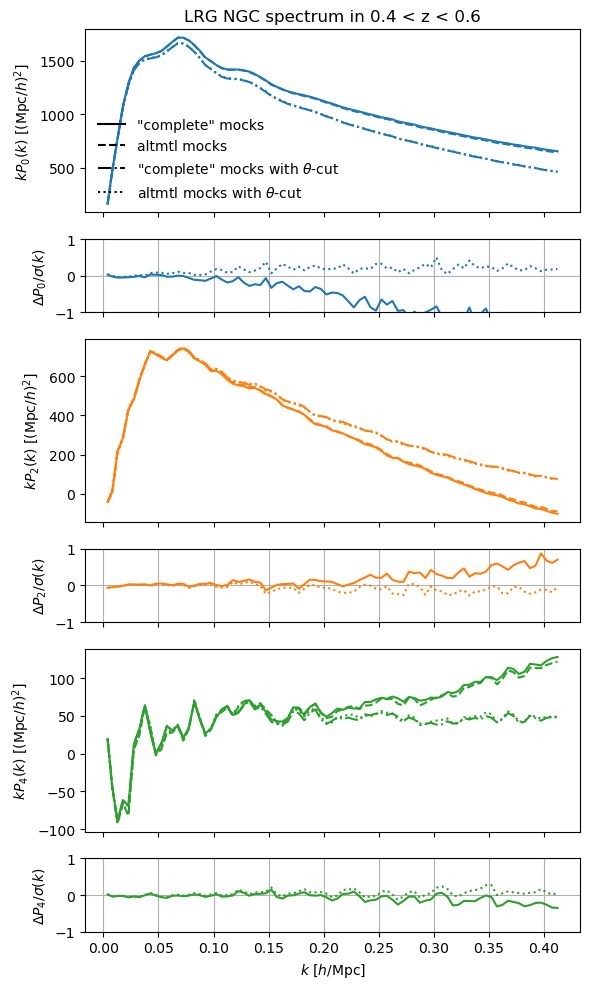

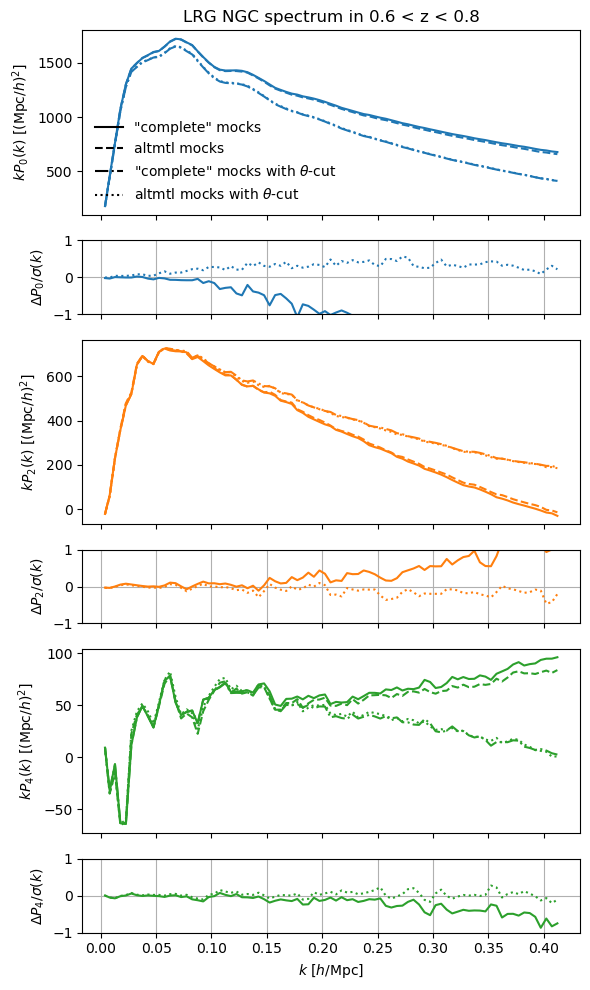

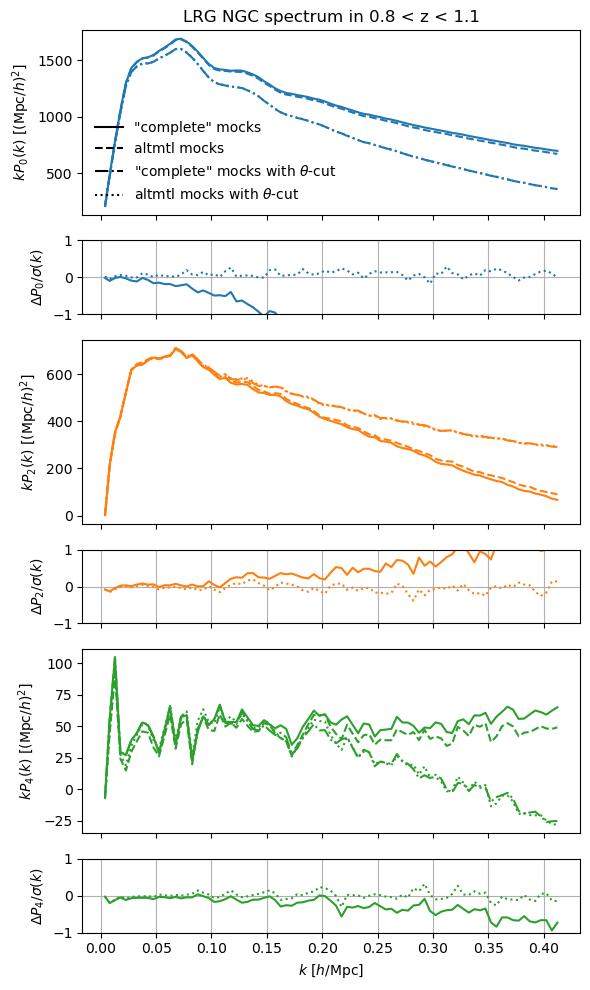

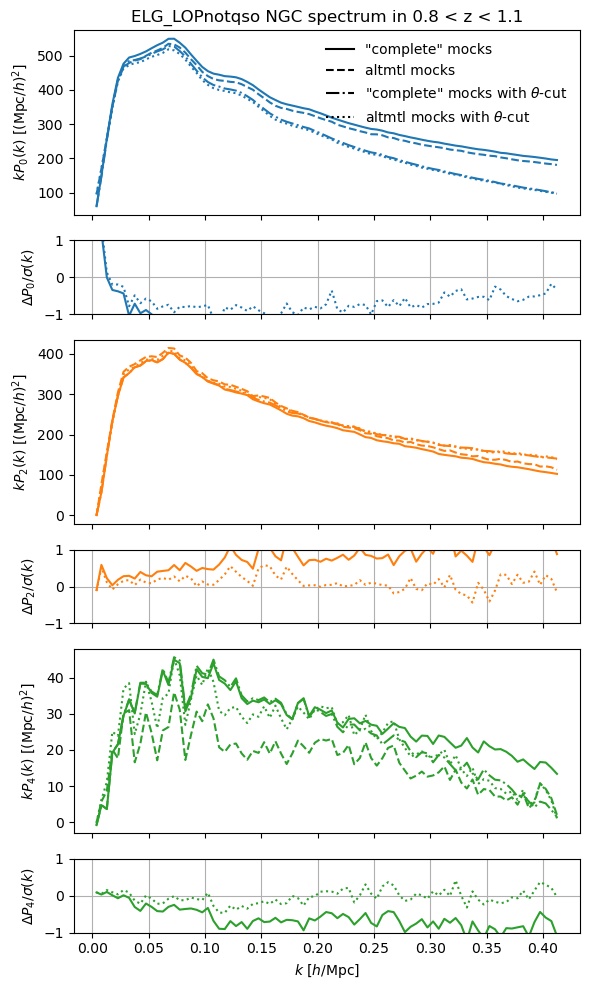

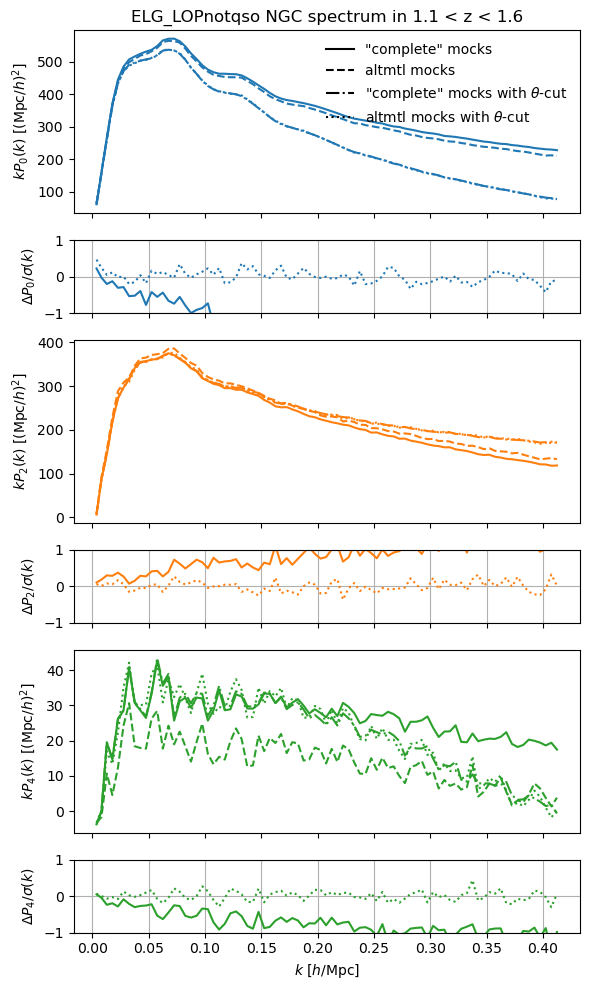

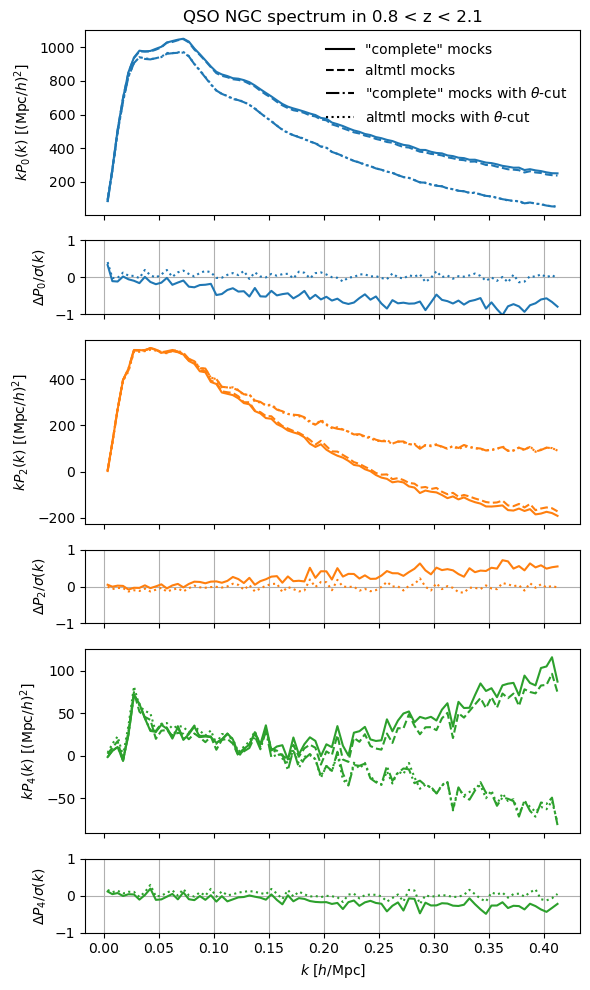

In [6]:
with_thetacut = True

for tracer in ['BGS_BRIGHT-21.35', 'LRG', 'ELG_LOPnotqso', 'QSO'][1:]:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum']:
            stats_dir = tools.base_stats_dir
            project = 'full_shape/fiber_assignment_systematics_tests'
            region = 'NGC'

            version = 'holi-v3-altmtl'
            if 'BGS' in tracer:
                version = 'holi-bgs-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean = cov.observable

            nmocks = 250
            #version = 'abacus-hf-dr2-v2-altmtl'
            version = 'glam-uchuu-v2-altmtl'
            if 'BGS' in tracer:
                version = 'abacus-2ndgen-dr2-altmtl'
                tracer = 'BGS_ANY-02'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP-noimsys', basis='sugiyama-diagonal', imock=imock) for imock in range(nmocks)]
    
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean = types.mean(mocks).match(mean)

            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra='complete',
                                      imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_complete = types.mean(mocks).match(mean)

            if with_thetacut:
                fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                          zrange=zrange, region=region, weight='default-FKP-noimsys', basis='sugiyama-diagonal', imock=imock, cut=True) for imock in range(nmocks)]
                mocks = [types.read(fn) for fn in fns if fn.exists()]
                mean_thetacut = types.mean(mocks).match(mean)
                fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                          zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock, extra='complete', cut=True) for imock in range(nmocks)]
                mocks = [types.read(fn) for fn in fns if fn.exists()]
                mean_complete_thetacut = types.mean(mocks).match(mean)

            nmocks = len(mocks)  # scale error bars

            if 'mesh2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    if with_thetacut:
                        pole = mean_complete_thetacut.get(ell)
                        ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-.')
                        pole = mean_thetacut.get(ell)
                        ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle='-')
                    if with_thetacut:
                        pole = mean_thetacut.get(ell)
                        pole_complete = mean_complete_thetacut.get(ell)
                        ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                if with_thetacut:
                    ax.plot([], [], color='k', linestyle='-.', label=r'"complete" mocks with $\theta$-cut')
                    ax.plot([], [], color='k', linestyle=':', label=r'altmtl mocks with $\theta$-cut')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_thetacut_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()

### Comparison of window-convolved box mocks and altmtl (w/o AUW) mocks

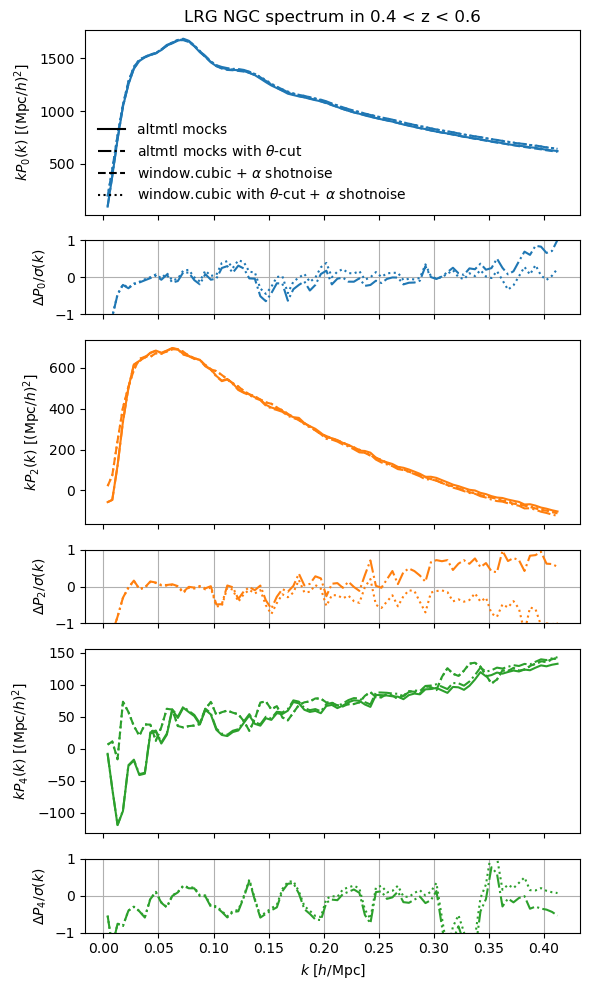

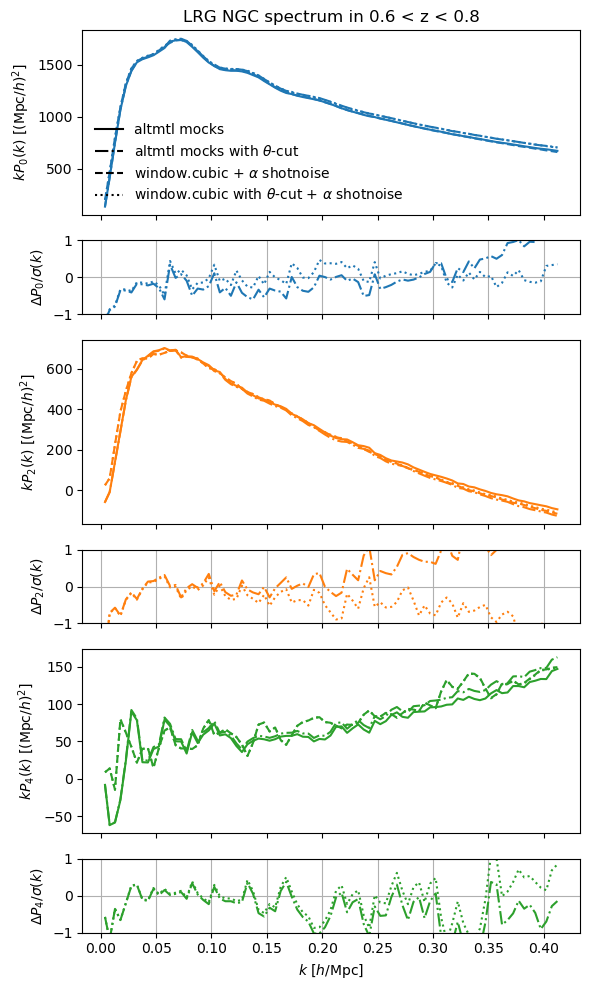

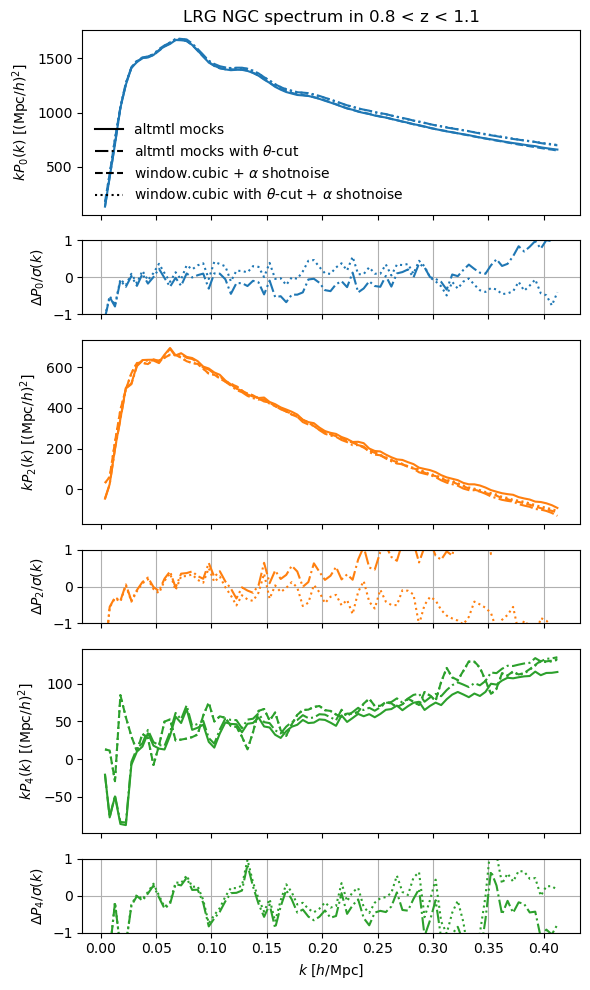

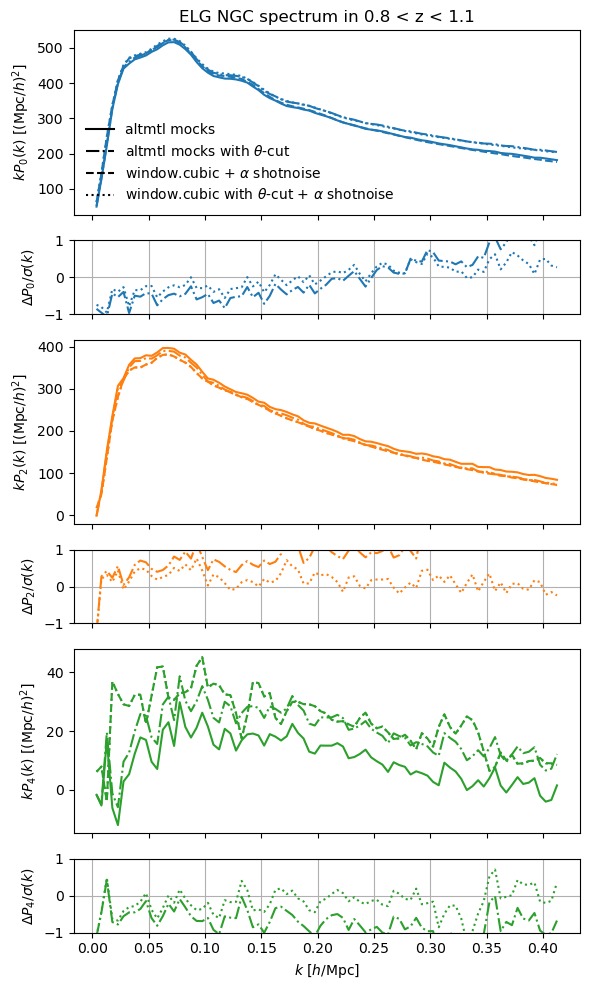

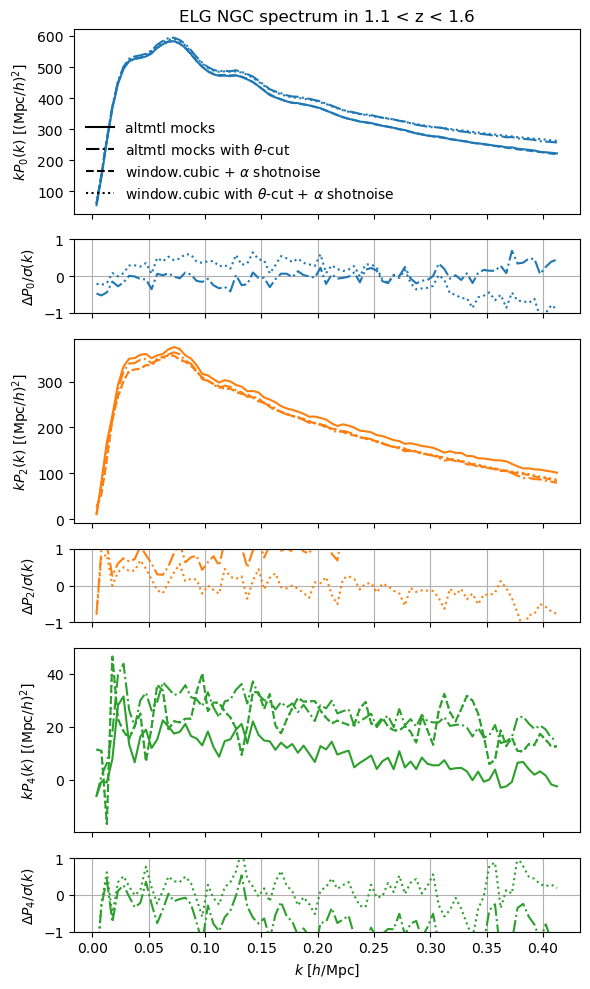

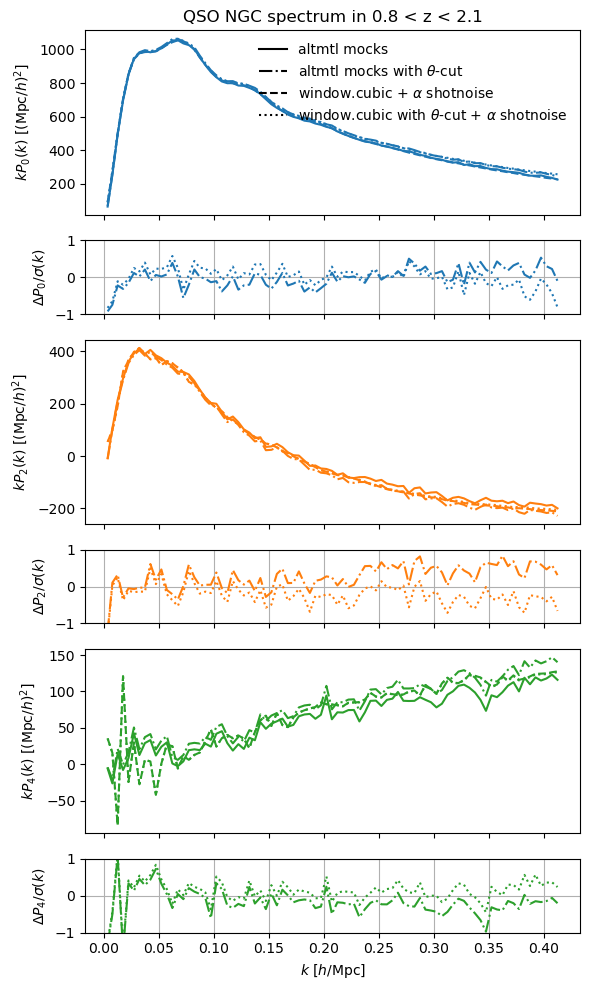

In [7]:
for tracer in ['LRG', 'ELG', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum']:
            nmocks = 25
            region = 'NGC'
            zsnap = box_tools.get_zsnap_from_z(tracer, zrange, version='abacus-hf-v2')
            stracer = tools.get_simple_tracer(tracer)
            stats_dir = tools.base_stats_dir
            hod = {'LRG': 'base_B', 'ELG': 'base_conf_nfwexp', 'QSO': 'base'}[stracer]
            fns = [box_tools.get_box_stats_fn(stats_dir=stats_dir, project='full_shape/box_window_function_validation', kind=kind, version='abacus-hf-v2', tracer=stracer,
                                              zsnap=zsnap, cosmo='000', hod=hod, los='z', basis='sugiyama', imock=imock) for imock in range(nmocks)]
            mocks_box = [types.read(fn) for fn in fns if fn.exists()]
            mean_box = types.mean(mocks_box)

            ftracer = tools.get_full_tracer(tracer, version='abacus-hf-dr2-v2-altmtl')
            fns = [tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=kind, version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(nmocks)]
            mocks_cutsky = [types.read(fn) for fn in fns if fn.exists()]
            mean_altmtl = types.mean(mocks_cutsky).select(k=slice(0, None, 5 if 'mesh2' in kind else 1))

            fns = [tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=kind, version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', auw=True, imock=imock) for imock in range(nmocks)]
            mocks_cutsky = [types.read(fn) for fn in fns if fn.exists()]
            mean_altmtl_thetacut = types.mean(mocks_cutsky).match(mean_altmtl)

            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version='holi-v3-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.match(mean_altmtl)

            def get_box_conv(window_cutsky, mean_box, mean_cutsky):
                mean_box_interp = []
                for label, pole in window_cutsky.theory.items():
                    pole_box = mean_box.get(ells=label['ells'])
                    if 'mesh3' in kind:
                        pole_box = pole_box.unravel()
                        from scipy import interpolate
                        mask1, mask2 = [np.any(pole_box.values('nmodes') > 0, axis=axis) for axis in [1, 0]]
                        spline = interpolate.RectBivariateSpline(pole_box.coords('k1')[mask1], pole_box.coords('k2')[mask2], pole_box.value()[np.ix_(mask1, mask2)], kx=1, ky=1, s=0)
                        pole = spline(*pole.coords('k').T, grid=False)
                    else:
                        mask = pole_box.values('nmodes') > 0
                        pole = np.interp(pole.coords('k'), pole_box.coords('k')[mask], pole_box.value()[mask], left=0., right=0)
                    mean_box_interp.append(pole)
                mean_box_interp = window_cutsky.theory.clone(value=np.concatenate(mean_box_interp))
                mean_box_conv = window_cutsky.dot(mean_box_interp, return_type=None)
                
                shotnoise = window_cutsky.theory.clone(value=0. * window_cutsky.theory.value()).value(concatenate=False)
                shotnoise[0] += next(iter(mean_cutsky)).values('shotnoise').mean()
                shotnoise = window_cutsky.dot(np.concatenate(shotnoise), return_type='nparray')[None, ...]
                precision = np.diag(1. / cov.std())
                # Solve d\chi^2 / drescale = 0, theory = rescale * shotnoise, data = mean_cutsky - mean_box_conv
                rescale = np.linalg.solve(shotnoise.dot(precision).dot(shotnoise.T), shotnoise.dot(precision).dot(mean_cutsky.value() - mean_box_conv.value()))
                mean_box_conv_shotnoise = mean_box_conv.clone(value=mean_box_conv.value() + rescale.dot(shotnoise))
                return mean_box_conv, mean_box_conv_shotnoise


            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_{kind}', version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                    zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=0)
            window_cutsky = types.read(fn).at.observable.match(mean_altmtl)
            mean_box_conv, mean_box_conv_shotnoise = get_box_conv(window_cutsky, mean_box, mean_altmtl)
            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_{kind}', version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                    zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', cut=True, imock=0)
            window_cutsky_thetacut = types.read(fn).at.observable.match(mean_altmtl)
            mean_box_conv_thetacut, mean_box_conv_shotnoise_thetacut = get_box_conv(window_cutsky_thetacut, mean_box, mean_altmtl_thetacut)
            #window_cutsky_thetacut = window_cutsky_thetacut#.at.theory.select(k=(0., 0.5))
            #diff = window_cutsky_thetacut.clone(value=window_cutsky_thetacut.value() - window_cutsky.at.theory.match(window_cutsky_thetacut.theory).value())
            #diff.plot(show=True)

            nmocks = min(len(mocks_box), len(mocks_cutsky))  # scale error bars
            if 'mesh2' in kind:
                ells = mean_altmtl.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_altmtl.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean_altmtl_thetacut.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-.')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    pole = mean_box_conv_shotnoise_thetacut.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    std = cov.at.observable.get(ell).std()
                    pole_cutsky = mean_altmtl.get(ell)
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(pole.coords('k'), (pole_cutsky.value() - pole.value()) / std, color=color, linestyle='-.')
                    pole_cutsky = mean_altmtl_thetacut.get(ell)
                    pole = mean_box_conv_shotnoise_thetacut.get(ell)
                    ax.plot(pole.coords('k'), (pole_cutsky.value() - pole.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label=r'altmtl mocks')
                ax.plot([], [], color='k', linestyle='-.', label=r'altmtl mocks with $\theta$-cut')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                ax.plot([], [], color='k', linestyle=':', label=r'window.cubic with $\theta$-cut + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_window_thetacut_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()